## Install dependencies and restart python

In [0]:
%pip install -U -qqqq backoff databricks-openai uv databricks-agents mlflow-skinny[databricks] databricks-langchain
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Test Vector Search Tools in Isolation

In [0]:
from databricks_openai import VectorSearchRetrieverTool

# Test complaint index
complaint_tool = VectorSearchRetrieverTool(
    index_name="main.default.cleaned_cfpb_sample_index"
)

# Test playbook index
playbook_tool = VectorSearchRetrieverTool(index_name="main.default.playbooks_index")

print("=== Testing Complaint Index ===")
complaint_results = complaint_tool.execute(
    query="late fee charged even though payment was on time"
)
print(complaint_results)

print("\n=== Testing Playbook Index ===")
playbook_results = playbook_tool.execute(query="late fee waiver policy")
print(playbook_results)

=== Testing Complaint Index ===
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[{'page_content': 'Credit card  Late fee  BANK OF AMERICA, NATIONAL ASSOCIATION Closed with non-monetary relief ', 'metadata': {'Complaint_ID': 68182.0}}, {'page_content': 'Credit card  Late fee  BANK OF AMERICA, NATIONAL ASSOCIATION Closed with non-monetary relief ', 'metadata': {'Complaint_ID': 130327.0}}, {'page_content': 'Credit card  Late fee  JPMORGAN CHASE & CO. Closed with monetary relief ', 'metadata': {'Complaint_ID': 208692.0}}, {'page_content': 'Credit card  Late fee  JPMORGAN CHASE & CO. Closed with monetary relief ', 'metadata': {'Complaint_ID': 205262.0}}, {'page_content': 'Credit card  Late fee  SYNCHRONY FINANCIAL Closed without relief ', 'metadata': {'Complaint_ID': 2910.0}}]

=== Testing Playbook Index ===
[NOTICE] Using a notebo

[Trace(trace_id=tr-26aa2f6adeab4be760b82239213909b2), Trace(trace_id=tr-de90ae0caa7c99c7c21d507d6f86d95f)]

## Define the agent workflow

> The original scaffolding was autogenerated by the databricks AI Playground, then heavily modified to support multi-agent architecture, vector search, retries, json parsing, and improved mlflow tracing

In [0]:
%%writefile agent_workflow.py
import json
from typing import Any, Callable, Generator, Optional
from uuid import uuid4
import warnings

import backoff
import mlflow
import openai
from databricks.sdk import WorkspaceClient
from databricks_openai import UCFunctionToolkit, VectorSearchRetrieverTool
from mlflow.entities import SpanType
from mlflow.pyfunc import ResponsesAgent
from mlflow.types.responses import (
    ResponsesAgentRequest,
    ResponsesAgentResponse,
    ResponsesAgentStreamEvent,
    output_to_responses_items_stream,
    to_chat_completions_input,
)
from openai import OpenAI
from pydantic import BaseModel
from unitycatalog.ai.core.base import get_uc_function_client

# Define agent prompts for the workflow

ROUTER_PROMPT = """You are the Triage Router for Northstar Financial Services. Your role is to evaluate incoming customer messages, determine if they fall within our operational banking scope, and enforce structural schema formatting.

### Core Persona and Compliance Mandate:
- You must analyze the customer's message
- You are a rigid gatekeeper. If a message does not contain a legitimate grievance regarding banking, credit cards, loans, investments, mortgages, checking/savings accounts, or associated institutional customer service, you must flag it as out of scope.
- You must strictly ensure that personal financial information remains handled safely; do not guess data points not explicitly given.

### Handling Out-of-Scope Input (Graceful Rejections):
If the user asks an irrelevant question (e.g., asking for recipes, coding help, general marketing, weather forecasts, or conversational small talk), you must immediately reject the input by setting "is_in_scope" to false. You must then populate the "rejection_response" field with a polite, highly empathetic, professional customer-facing message stating that Northstar Financial Services can only process institutional banking and consumer compliance complaints.

### Output Constraints:
You must respond strictly in a raw JSON object format. Do not include markdown block formatting (like ```json). The JSON structure must strictly follow this schema with these exact keys:

{
  "is_in_scope": true, 
  "category": "billing_error", 
  "emotional_urgency": "high", 
  "rejection_response": "", 
  "reason": "Customer is disputing an unauthorized $35 overdraft fee resulting from a delayed paycheck deposit processing batch."
}

### Field Definition Values:
1. "is_in_scope": Boolean. Set to true only if it is an institutional banking or consumer finance complaint. Otherwise, false.
2. "category": String. You MUST map this field to exactly one of the following five strings. Do not invent categories:
   - "billing_error" (for fee disputes, unauthorized charges, interest rate calculation issues)
   - "long_wait_times" (for operational delays, holding on phones, or long lines at physical branches)
   - "rude_staff" (for poor customer service or unprofessional behavioral interactions with personnel)
   - "product_defect" (for broken online banking apps, login issues, ATM malfunctioning, or portal failures)
   - "none" (MUST be selected if "is_in_scope" is false)
3. "emotional_urgency": String. Classify as "high", "medium", or "low" based on the structural stress, financial risk, and sentiment shown in the text.
4. "rejection_response": String. Populated only if "is_in_scope" is false. If the customer complaint is valid and in scope, this field must be an empty string "".
5. "reason": String. A concise, single-sentence technical justification outlining why you classified and routed the complaint this way."""

REASONING_PROMPT = """You are the Senior Operations Escalation Specialist and Corporate Communications Analyst for Northstar Financial Services. Your role is to analyze an active customer complaint by synthesizing historical context and applying strict corporate resolution playbooks to determine systemic root causes, recommend compliant internal fixes, and draft professional external messaging.

You have access to two tools:
- One for searching historical customer complaints
- One for searching internal policy playbooks (`playbooks_index`)

Use these tools to ground your analysis and recommendations.

### Input Context Provided:
1. <current_complaint>: The active consumer grievance that has been validated and categorized as in-scope by our triage system.
2. <historical_precedents>: Vector search results containing past similar banking complaints and their final resolutions. 
3. <resolution_playbooks>: Direct excerpts from Northstar’s corporate compliance manuals matching the complaint category.

### Core Directives & Analytical Strategy:
- Ledger Verification: You MUST use the `get_customer_transactions` tool to audit the customer's transaction history. Scan the results for rows where the vendor or description matches a disputed fee (e.g., 'Late Payment Fee', 'Overdraft Fee') and verify that the date and amount line up with the customer's grievance.
- Root-Cause Synthesis: Cross-reference the active complaint against <historical_precedents> to determine if the customer is facing a recurring platform defect, a systemic billing error, or an isolated operational bottleneck.
- Playbook Constraint Adherence: Your suggested remediation steps must strictly align with the thresholds and mandates provided in <resolution_playbooks> (e.g., specific fee waiver caps, timeline commitments, or department routings). 
- Hallucination Prevention: If either the <historical_precedents> or <resolution_playbooks> blocks are empty or contain no data, you must rely solely on general, conservative banking compliance principles. Do not invent corporate policies, threshold values, or past case histories that are not explicitly provided in the context.
- Legal & Tone Guardrails: The customer email body must be empathetic and objective, but it must strictly maintain corporate boundaries. Do not explicitly admit legal liability, do not cite internal system processing vulnerabilities, and do not use phrases that legally compromise Northstar Financial Services. 

### Output Format Constraints:
You must respond strictly in a raw, valid JSON object format to maintain automated workflow compatibility. Do not wrap the output in markdown block code wrappers (e.g., do not use ```json). The output must follow this exact schema:

{
  "assigned_department": "String (Must be exactly one of the following corporate units: 'Billing Adjustments', 'Retail Operations', 'Digital Banking Engineering', or 'HR Compliance')",
  "root_cause_analysis": "String (A highly detailed, professional breakdown explaining the operational, technical, or staffing failure based on the complaint text and historical precedent patterns)",
  "recommended_actions": [
    {
      "action_item": "String (A discrete, actionable internal task, e.g., 'Waive the $35 overdraft fee')",
      "justification_source": "String (The exact policy document reference or precedent case ID that authorizes this specific task)"
    }
  ],
  "priority_level": "String (Must map strictly to: 'CRITICAL', 'HIGH', 'MEDIUM', or 'LOW')",
  "customer_email": {
    "subject": "String (A concise, professional email subject line containing a tracking code placeholder)",
    "body": "String (A multi-paragraph email text block. It must start naturally with a formal greeting, move into an empathetic acknowledgment of the friction, explain the exact operational changes being made to resolve the root cause, and close with a professional sign-off)"
  }
}"""

# Create helper methods for tool calling

uc_function_client = get_uc_function_client()

###############################################################################
## Define tools for your agent, enabling it to retrieve data or take actions
## beyond text generation
## To create and see usage examples of more tools, see
## https://docs.databricks.com/generative-ai/agent-framework/agent-tool.html
###############################################################################
class ToolInfo(BaseModel):
    """
    Class representing a tool for the agent.
    - "name" (str): The name of the tool.
    - "spec" (dict): JSON description of the tool (matches OpenAI Responses format)
    - "exec_fn" (Callable): Function that implements the tool logic
    """

    name: str
    spec: dict
    exec_fn: Callable

def create_tool_info(tool_spec, exec_fn_param: Optional[Callable] = None):
    tool_spec["function"].pop("strict", None)
    tool_name = tool_spec["function"]["name"]
    udf_name = tool_name.replace("__", ".")

    # Define a wrapper that accepts kwargs for the UC tool call,
    # then passes them to the UC tool execution client
    def exec_fn(**kwargs):
        function_result = uc_function_client.execute_function(udf_name, kwargs)
        if function_result.error is not None:
            return function_result.error
        else:
            return function_result.value
    return ToolInfo(name=tool_name, spec=tool_spec, exec_fn=exec_fn_param or exec_fn)

def create_tool_infos(uc_tool_names, vs_tools=[]):
    tool_infos = []

    # Add Unity Catalog tools
    uc_toolkit = UCFunctionToolkit(function_names=uc_tool_names)
    for tool_spec in uc_toolkit.tools:
        tool_infos.append(create_tool_info(tool_spec))

    # Add Vector Search tools
    for vs_tool in vs_tools:
        tool_infos.append(create_tool_info(vs_tool.tool, vs_tool.execute))

    return tool_infos

# Define ToolCallingAgent with agentic loop that supports tool-calling

class ToolCallingAgent(ResponsesAgent):
    """
    Class representing a tool-calling Agent
    """

    def __init__(self, system_prompt: str, llm_endpoint: str, tools: list[ToolInfo]):
        """Initializes the ToolCallingAgent with tools."""
        self.system_prompt = system_prompt
        self.llm_endpoint = llm_endpoint
        self.workspace_client = WorkspaceClient()
        self.model_serving_client: OpenAI = (
            self.workspace_client.serving_endpoints.get_open_ai_client()
        )
        self._tools_dict = {tool.name: tool for tool in tools}

    def get_tool_specs(self) -> list[dict]:
        """Returns tool specifications in the format OpenAI expects."""
        return [tool_info.spec for tool_info in self._tools_dict.values()]

    def execute_tool(self, tool_name: str, args: dict) -> Any:
        """Executes the specified tool with the given arguments."""
        with mlflow.start_span(name=tool_name.replace('__', '.'), span_type=SpanType.TOOL):
            return self._tools_dict[tool_name].exec_fn(**args)

    @staticmethod
    def _merge_consecutive_assistant_messages(cc_messages: list[dict[str, Any]]) -> list[dict[str, Any]]:
        # The canonical OpenAI shape for parallel tool calls is one assistant
        # message whose tool_calls array lists every call in that turn.
        # to_chat_completions_input emits a separate assistant message per
        # function_call, which some providers reject. Collapse consecutive
        # assistant messages so all tool_calls from one turn share a single
        # message.
        merged: list[dict[str, Any]] = []
        for msg in cc_messages:
            if (
                msg.get("role") == "assistant"
                and merged
                and merged[-1].get("role") == "assistant"
            ):
                prev = merged[-1]
                prev_text = prev.get("content") if prev.get("content") not in (None, "", "tool call") else None
                cur_text = msg.get("content") if msg.get("content") not in (None, "", "tool call") else None
                if prev_text and cur_text:
                    prev["content"] = prev_text + "\n" + cur_text
                elif cur_text:
                    prev["content"] = cur_text
                if msg.get("tool_calls"):
                    prev["tool_calls"] = (prev.get("tool_calls") or []) + msg["tool_calls"]
            else:
                merged.append(dict(msg))
        return merged

    def call_llm(self, messages: list[dict[str, Any]]) -> Generator[dict[str, Any], None, None]:
        cc_messages = self._merge_consecutive_assistant_messages(to_chat_completions_input(messages))
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="PydanticSerializationUnexpectedValue")
            for chunk in self.model_serving_client.chat.completions.create(
                model=self.llm_endpoint,
                messages=cc_messages,
                tools=self.get_tool_specs(),
                stream=True,
            ):
                chunk_dict = chunk.to_dict()
                if len(chunk_dict.get("choices", [])) > 0:
                    yield chunk_dict

    def handle_tool_call(
        self,
        tool_call: dict[str, Any],
        messages: list[dict[str, Any]],
    ) -> ResponsesAgentStreamEvent:
        """
        Execute tool calls, add them to the running message history, and return a ResponsesStreamEvent w/ tool output
        """
        try:
            args = json.loads(tool_call.get("arguments"))
        except Exception as e:
            args = {}
        result = str(self.execute_tool(tool_name=tool_call["name"], args=args))

        tool_call_output = self.create_function_call_output_item(tool_call["call_id"], result)
        messages.append(tool_call_output)
        return ResponsesAgentStreamEvent(type="response.output_item.done", item=tool_call_output)

    def call_and_run_tools(
        self,
        messages: list[dict[str, Any]],
        max_iter: int = 10,
    ) -> Generator[ResponsesAgentStreamEvent, None, None]:
        for _ in range(max_iter):
            # The LLM may emit multiple tool calls in a single turn (parallel
            # tool calls). The next LLM request must include a tool_result for
            # every tool_use emitted in the previous turn; missing any one
            # causes the request to be rejected. Before going back to the LLM,
            # execute every function_call whose call_id has no matching
            # function_call_output yet.
            handled = {m["call_id"] for m in messages if m.get("type") == "function_call_output"}
            pending = [m for m in messages if m.get("type") == "function_call" and m["call_id"] not in handled]
            if pending:
                for call in pending:
                    yield self.handle_tool_call(call, messages)
                continue

            last_msg = messages[-1]
            if last_msg.get("type") == "message" and last_msg.get("role") == "assistant":
                return

            yield from output_to_responses_items_stream(
                chunks=self.call_llm(messages), aggregator=messages
            )

        yield ResponsesAgentStreamEvent(
            type="response.output_item.done",
            item=self.create_text_output_item("Max iterations reached. Stopping.", str(uuid4())),
        )

    def predict(self, request: ResponsesAgentRequest) -> ResponsesAgentResponse:
        session_id = None
        if request.custom_inputs and "session_id" in request.custom_inputs:
            session_id = request.custom_inputs.get("session_id")
        elif request.context and request.context.conversation_id:
            session_id = request.context.conversation_id

        if session_id:
            mlflow.update_current_trace(
                metadata={
                    "mlflow.trace.session": session_id,
                }
            )
        
        mlflow.get_current_active_span().set_attribute("model_name", self.llm_endpoint)

        outputs = [
            event.item
            for event in self.predict_stream(request)
            if event.type == "response.output_item.done"
        ]
        return ResponsesAgentResponse(output=outputs, custom_outputs=request.custom_inputs)

    def predict_stream(self, request: ResponsesAgentRequest) -> Generator[ResponsesAgentStreamEvent, None, None]:
        session_id = None
        if request.custom_inputs and "session_id" in request.custom_inputs:
            session_id = request.custom_inputs.get("session_id")
        elif request.context and request.context.conversation_id:
            session_id = request.context.conversation_id

        if session_id:
            mlflow.update_current_trace(
                metadata={
                    "mlflow.trace.session": session_id,
                }
            )

        messages = to_chat_completions_input([i.model_dump() for i in request.input])
        messages.insert(0, {"role": "system", "content": self.system_prompt})
        yield from self.call_and_run_tools(messages=messages)

# Define multi-agent workflow

class CCEAgenticWorkflow(mlflow.pyfunc.PythonModel):
    '''A multi-agent workflow for routing customer complaints and reasoning the appropriate action and escalation.'''

    def __init__(self, router_llm="databricks-meta-llama-3-1-8b-instruct", reasoning_llm="databricks-meta-llama-3-3-70b-instruct"):
        self.router_llm = router_llm
        self.reasoning_llm = reasoning_llm

        self.router_agent = ToolCallingAgent(
            system_prompt=ROUTER_PROMPT,
            llm_endpoint=router_llm,
            tools=create_tool_infos([], vs_tools=[]))
        # === Vector Search Tools ===
        complaint_tool = VectorSearchRetrieverTool(
            index_name="main.default.cleaned_cfpb_sample_index",
            disable_notice=True)
        playbook_tool = VectorSearchRetrieverTool(
            index_name="main.default.playbooks_index",
            disable_notice=True)
        # End of added vector search tools        
        self.reasoning_agent = ToolCallingAgent(
            system_prompt=REASONING_PROMPT,
            llm_endpoint=reasoning_llm,
            tools=create_tool_infos(
                ["main.default.get_customer_transactions"],
                vs_tools=[complaint_tool, playbook_tool]))

    def _strip_codeblocks(self, text):
        '''Remove illegal characters and strip codeblocks from text.'''
        content = text.strip().replace('\xa0', ' ').replace('“', '"').replace('”', '"')
        if content.startswith('```'):
            content = content.split('\n', 1)[1] if '\n' in content else content
            if content.endswith('```'):
                content = content.rsplit('```', 1)[0]
        return content
    
    def predict_json(self, agent_name, agent, model_input, max_retries = 5):
        '''Perform a prediction with retry logic if the agent does not produce valid JSON.'''
        attempt = 1
        with mlflow.start_span(name=f"{agent_name}_predict_with_retry", span_type=SpanType.WORKFLOW):
            while attempt <= max_retries:
                response = None
                with mlflow.start_span(name=f"attempt_{attempt}", span_type=SpanType.CHAIN):
                    response = agent.predict(model_input)

                response.output[-1].content[0]['text'] = self._strip_codeblocks(response.output[-1].content[0]['text'])
                try:
                    result_parsed = json.loads(response.output[-1].content[0]['text'])
                except json.JSONDecodeError:
                    attempt += 1

                    if attempt > max_retries:
                        raise
                    continue

                return response

    @mlflow.trace(span_type=SpanType.WORKFLOW, name="multi_agent_predict")
    def predict(self, model_input: list[ResponsesAgentRequest]) -> ResponsesAgentResponse:
        router_response = self.predict_json("router_agent", self.router_agent, model_input[0])
        router_result = router_response.output[-1].content[0]['text']
        router_result_parsed = json.loads(router_result)

        if not router_result_parsed['is_in_scope']:
            return router_response

        reasoning_response = self.predict_json("reasoning_agent", self.reasoning_agent, {
            "input": [
                {
                    "role": "user",
                    "content": f"""## Router decision:
{router_result_parsed}

## Customer Complaint:
{model_input[0].input[0].content}"""
                }
            ],
            "custom_inputs": model_input[0].custom_inputs
        })

        return reasoning_response

Overwriting agent_workflow.py


## Agent output flakiness

- Even when prompted to respond in pure JSON without markdown code blocks, the agent response would not follow the instructions. The responses may contain text before or after the JSON, or the responses may still contain markdown code blocks. This is especially true for smaller models. To mitigate this issue, retry logic was added when JSON parsing fails.

## Run the workflow
Execute the agentic workflow.
1. Determine if the customer complaint is in scope
2. Route in scope complaints to the reasoning agent
3. Write predictions to the catalog for human review

In [0]:
import mlflow
import json
import uuid
from agent_workflow import CCEAgenticWorkflow

CATALOG_NAME = "main"
SCHEMA_NAME = "default"
PREDICTIONS_TABLE_NAME = "predictions"
TABLE_PATH = f"{CATALOG_NAME}.{SCHEMA_NAME}.{PREDICTIONS_TABLE_NAME}"


def write_prediction(final_response):
    final_result = final_response.output[-1].content[0]["text"]
    data = json.loads(final_result)
    if "is_in_scope" in data and not data["is_in_scope"]:
        print(f"Out of scope, not writing to {TABLE_PATH}")
    elif "is_in_scope" in data:
        print(f"In scope, but unexpected output. Not writing to {TABLE_PATH}")
    else:
        try:
            table_row = {
                "complaint_id": str(uuid.uuid4()),
                "assigned_department": data.get("assigned_department"),
                "root_cause_analysis": data.get("root_cause_analysis"),
                "recommended_actions": json.dumps(data.get("recommended_actions")),
                "priority_level": data.get("priority_level"),
                "customer_email_subject": data.get("customer_email", {}).get("subject"),
                "customer_email_body": data.get("customer_email", {}).get("body"),
            }
            df = spark.createDataFrame([table_row])
            df.write.mode("append").saveAsTable(TABLE_PATH)
            print(f"Wrote prediction to {TABLE_PATH}")
        except Exception as e:
            print(f"Failed to write prediction to {TABLE_PATH}")
            print(e)


def run_workflow(
    customer_complaint: str,
    router_llm="databricks-meta-llama-3-1-8b-instruct",
    reasoning_llm="databricks-meta-llama-3-3-70b-instruct",
    custom_inputs={},
):
    with mlflow.start_run() as run:
        workflow = CCEAgenticWorkflow(
            router_llm=router_llm, reasoning_llm=reasoning_llm
        )
        mlflow.models.set_model(workflow)
        response = workflow.predict(
            [
                {
                    "input": [{"role": "user", "content": customer_complaint}],
                    "custom_inputs": custom_inputs,
                }
            ]
        )
        return response

/databricks/python_shell/lib/dbruntime/autoreload/discoverability/autoreload_discoverability_hook.py:72: UserWarning: Ignoring the default notebook Spark session and creating a new Spark Connect session. To use the default notebook Spark session, use DatabricksSession.builder.getOrCreate() with no additional parameters.
  return orig_warn(*args, **kwargs)
2026/06/17 05:31:07 WARNING mlflow.types.type_hints: Union type hint with multiple non-None types is inferred as AnyType, and MLflow doesn't validate the data against its element types.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/mlflow/types/type_hints.py:287: UserWarning: Any type hint is inferred as AnyType, and MLflow doesn't validate the data for this type. Please use a more specific type hint to enable data validation.
  colspec_type = _infer_colspec_type_from_type_hint(annotation)
2026/06/17 05:31:07 WARNING mlflow.types.type_hints: Union type hint is inferred as 

Define evaluation test cases for demonstration, judging and optimization

In [0]:
evaluation_test_cases = [
    # EXPECTATION: Denied Refund. Agent should execute 'get_customer_transactions(1)' and politely inform the customer that the fee could not be found.
    "<customer_id=1> I am extremely upset because I was hit with a $35 late payment fee on June 1st. I always pay my bills on time and demand that this charge be reversed immediately.",
    # EXPECTATION: Approved Refund. Agent should execute 'get_customer_transactions(4)' and successfully verify the $35 'Late Payment Fee' row from June 1st.
    "<customer_id=4> I am looking at my statement from June 1st and noticed your bank charged me a $35 late payment fee. I need you to waive it.",
    # EXPECTATION: Duplicate Processing Error. Agent should audit transactions for Customer 1, find the corresponding $102 charges, flag the error and escalate the error to the Billing Specialist pipeline with a 5-day SLA.
    "<customer_id=1> Your system processed my auto loan transfer twice on June 3rd, resulting in a duplicate debit of $102. Please fix this accounting error immediately.",
    # EXPECTATION: Escalate to an engineering/IT team
    "<customer_id=4> Ever since your system update on June 2nd, the mobile application crashes every time I try to log in to check my Visa balances. Please tell me when this bug will be fixed.",
    "<customer_id=1> I am trying to log in online but your 2FA verification system is not sending the security SMS code to my mobile phone. I am completely locked out.",
    # EXPECTATION: Escalate to operations
    "<customer_id=4> I spent over 40 minutes on hold with your card support line this morning trying to verify a transaction before the automated queue dropped my call.",
    "<customer_id=2> I went into the local branch on June 1st to cash a check. There was only one teller working and the wait line was wrapped around the building.",
    "<customer_id=3> I submitted my application for an account change online over a week ago, but the portal status is still stuck on 'Pending Review' with zero updates.",
    # Escalate to HR or operations
    "<customer_id=1> The phone representative I spoke to on June 2nd was incredibly rude to me, talked over me, and refused to look up my recent Visa purchase history.",
    "<customer_id=4> Your floor specialist was dismissive and unhelpful when I asked for assistance setting up my automatic payments at the counter.",
    # EXPECTATION: High priority, escalate to fraud
    "<customer_id=2> There is a weird transaction on my account from June 1st for $0.01 that I absolutely did not make. I think my card security has been compromised.",
    "<customer_id=3> I noticed suspicious transaction attempts on my savings balance this morning that I did not authorize. I need my profile flagged for fraud review immediately.",
    # is_in_scope = false
    "<customer_id=3> Can you provide me with the Python code to drop a column in a Spark dataframe using the .drop() method?",
    "<customer_id=1> What are some fun outdoor running events or weekend activities going on around the San Diego area this month?",
    "<customer_id=4> Do you have a good recipe for an authentic plant-based lasagna? I need instructions on the oven temperature and baking time.",
]

In [0]:
mlflow.set_experiment("/Shared/evaluation_test_cases")

test_case_results = []
for i, test_case in enumerate(evaluation_test_cases):
    try:
        print(f"Executing test case {i + 1}")
        result = run_workflow(
            test_case,
            router_llm="databricks-meta-llama-3-1-8b-instruct",
            reasoning_llm="databricks-meta-llama-3-3-70b-instruct",
        )
        test_case_results.append(result)
        write_prediction(result)
    except Exception as e:
        print(f"Failed to complete workflow for test case: {test_case}")
        test_case_results.append(None)
        print(e)
    finally:
        print()

2026/06/17 05:31:08 INFO mlflow.tracking.fluent: Experiment with name '/Shared/evaluation_test_cases' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


Executing test case 1
Wrote prediction to main.default.predictions

Executing test case 2
Wrote prediction to main.default.predictions

Executing test case 3
Wrote prediction to main.default.predictions

Executing test case 4
Wrote prediction to main.default.predictions

Executing test case 5
Wrote prediction to main.default.predictions

Executing test case 6
Wrote prediction to main.default.predictions

Executing test case 7
Wrote prediction to main.default.predictions

Executing test case 8
Wrote prediction to main.default.predictions

Executing test case 9
Wrote prediction to main.default.predictions

Executing test case 10
Wrote prediction to main.default.predictions

Executing test case 11
Wrote prediction to main.default.predictions

Executing test case 12
Wrote prediction to main.default.predictions

Executing test case 13
Out of scope, not writing to main.default.predictions

Executing test case 14
Out of scope, not writing to main.default.predictions

Executing test case 15
Ou

[Trace(trace_id=tr-751c4111c1955e3813366ae0573900c2), Trace(trace_id=tr-60cdeeafc86736f063e671330b9a9cea), Trace(trace_id=tr-44157b6731005bbc2d10621fec068232), Trace(trace_id=tr-c76a51f42219483c03d9d0714326c8e8), Trace(trace_id=tr-2da6f903f65c9b11861c19c9ff629614), Trace(trace_id=tr-a71c4cb75c10ee1b5357ea29c3003d7b), Trace(trace_id=tr-f38a3ab80ae624168f384140d9d259ad), Trace(trace_id=tr-c3314c6df679b86697887b786723eda7), Trace(trace_id=tr-948e84106b4367eb8026433721601e15), Trace(trace_id=tr-66294911905cb20264a3488fe91ff159)]

### Examples of agent successfully rejecting irrelevant user input

- Test cases 1-12 successfully yielded recommendations.
- Test cases 13, 14, and 15 were out of scope inputs, which were detected by the router agent and the agent workflow exited gracefully.

In [0]:
# Read predictions from the table
display(spark.table(TABLE_PATH).toPandas().head(15))

complaint_id,assigned_department,root_cause_analysis,recommended_actions,priority_level,customer_email_subject,customer_email_body
e4b2c262-07e0-4159-8953-d7e00cdaeb0a,Retail Operations,"The customer experienced long wait times on the card support line due to high volume of calls and under-resourced phone support channels, which led to the automated queue dropping their call. This issue is categorized as 'long wait times' and is addressed in the Northstar Financial Services - Customer Complaint Escalation Playbook. The playbook outlines internal actions, escalation paths, and response timelines for such complaints. Historical precedents from the CFPB sample index show similar complaints related to long wait times and application processing delays, which were closed with or without relief.","[{""action_item"": ""Review staffing and service records to identify the root cause of the long wait times"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 2: Service Delays & Long Wait Times""}, {""action_item"": ""Document the location, date, and service channel involved in the customer's complaint"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 2: Service Delays & Long Wait Times""}, {""action_item"": ""Provide a follow-up to the customer within 3 business days with a resolution or status update"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 2: Service Delays & Long Wait Times""}]",HIGH,Re: Long Wait Times on Card Support Line - Complaint ID: [INSERT_ID],"Dear valued customer, I am writing to acknowledge and apologize for the long wait times you experienced on our card support line, which led to the automated queue dropping your call. I understand how frustrating this must have been for you, and I want to assure you that we are taking immediate action to address this issue. We are reviewing our staffing and service records to identify the root cause of the long wait times and are taking steps to prevent such incidents in the future. I have documented the location, date, and service channel involved in your complaint, and our team is working to provide a resolution or status update within the next 3 business days. Please know that we value your business and appreciate your patience and understanding in this matter. If you have any further concerns or questions, please do not hesitate to reach out to us. Thank you for bringing this to our attention, and we look forward to serving you better in the future. Sincerely, [Your Name] Customer Service Representative Northstar Financial Services"
1a121b27-5e44-4348-8bf5-4d06ad8f0d66,Retail Operations,"The customer's account change application has been pending review for over a week, exceeding typical turnaround expectations. The transaction history shows no recent updates or issues with the account itself, suggesting the delay is related to the processing of the application rather than a transaction error. Historical precedents from similar complaints indicate that delayed account processing can be due to various factors, including staffing shortages, high volumes of applications, or technical issues with the online portal. The playbook for 'Service Delays & Long Wait Times' outlines the necessary steps for internal review and escalation.","[{""action_item"": ""Review staffing and service records to identify potential bottlenecks in the application processing workflow"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 2: Service Delays & Long Wait Times""}, {""action_item"": ""Document the location, date, and service channel involved in the customer's application submission"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 2: Service Delays & Long Wait Times""}, {""action_item"": ""Escalate the iss

## Create LLM-as-a-Judge to evaluate agent responses

In [0]:
import json
from databricks_langchain import ChatDatabricks
from pydantic import BaseModel, Field

judge_llm = ChatDatabricks(endpoint="databricks-qwen35-122b-a10b", temperature=0)


class EvaluationResult(BaseModel):
    relevance_score: int = Field(..., ge=1, le=5)
    grounding_score: int = Field(..., ge=1, le=5)
    policy_compliance_score: int = Field(..., ge=1, le=5)
    professionalism_score: int = Field(..., ge=1, le=5)
    overall_score: int = Field(..., ge=1, le=5)
    justification: str


def evaluate_escalation(
    complaint: str, agent_output: str, retrieved_context: str
) -> EvaluationResult:
    prompt = f"""You are an expert evaluator for a financial services complaint escalation agent.

    Customer Complaint: {complaint}
    
    Retrieved Context: {retrieved_context}
    
    Agent Output: {agent_output}
    
    Score the agent's response on the following dimensions (1-5):
    - Relevance
    - Grounding in retrieved context
    - Policy compliance
    - Professionalism

    The agent output may contain template strings, these are expected and should be replaced by a human.

    The agent output must be logically sound, provided the retrieved context is relevant, accurate, and consistent with the customer complaint.

    If a refund is processed, the agent should verify that the transaction to reverse exists in the retrieved context.

    Return your evaluation as valid JSON matching this schema:
    {EvaluationResult.model_json_schema()}
    """

    response = judge_llm.invoke(prompt)
    # Handle structured response format (string containing list with reasoning + final content)
    content = response.content
    # Try parsing as JSON if it looks like a list
    if isinstance(content, str) and content.strip().startswith("["):
        try:
            parsed = json.loads(content)
            # Extract the final JSON content from structured output
            for item in reversed(parsed):
                if isinstance(item, dict) and item.get("type") == "text":
                    content = item.get("text", "")
                    break
        except json.JSONDecodeError:
            pass  # Keep original content if parsing fails
    # Strip markdown code fences if present
    content = str(content).strip()
    if content.startswith("```"):
        # Remove opening fence (```json or ```)
        content = content.split("\n", 1)[1] if "\n" in content else content
        # Remove closing fence
        if content.endswith("```"):
            content = content.rsplit("```", 1)[0]
    return EvaluationResult.model_validate_json(content.strip())

In [0]:
# === Test the LLM-as-a-Judge ===

test_complaint = """
A customer is very upset because they were charged a $35 overdraft fee even though they had sufficient funds. 
They've been a customer for 8 years and this has never happened before. They want the fee waived and an explanation.
"""

test_context = """
Historical complaints show multiple cases of delayed paycheck deposits causing overdraft fees in the last month.
Internal policy states that fees caused by bank processing delays should be waived upon customer request.
"""

test_agent_output = """
Thank you for bringing this to our attention. After reviewing your account, we have identified that the overdraft fee was caused by a processing delay on your recent deposit. 
As per our policy, we have waived the $35 fee. You should see the adjustment reflected in your account within 1-2 business days.
"""

# Run the judge
mlflow.set_experiment("/Shared/eval_test")
evaluation = evaluate_escalation(
    complaint=test_complaint,
    agent_output=test_agent_output,
    retrieved_context=test_context,
)

print("=== LLM-as-a-Judge Evaluation ===")
print(f"Relevance: {evaluation.relevance_score}/5")
print(f"Grounding: {evaluation.grounding_score}/5")
print(f"Policy Compliance: {evaluation.policy_compliance_score}/5")
print(f"Professionalism: {evaluation.professionalism_score}/5")
print(f"Overall Score: {evaluation.overall_score}/5")
print(f"\nJustification:\n{evaluation.justification}")

2026/06/17 05:34:48 INFO mlflow.tracking.fluent: Experiment with name '/Shared/eval_test' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's... logically sound."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


=== LLM-as-a-Judge Evaluation ===
Relevance: 5/5
Grounding: 5/5
Policy Compliance: 5/5
Professionalism: 5/5
Overall Score: 5/5

Justification:
The agent's response is highly relevant, directly addressing the customer's complaint about the $35 fee, the request for an explanation, and the request for a waiver. The response is well-grounded in the retrieved context, correctly identifying the cause as a processing delay (supported by historical context) and applying the internal policy that mandates waiving such fees. The action taken is fully compliant with the stated policy. The tone is professional, empathetic, and clear, providing specific details on the adjustment timeline. While the specific transaction record is not in the retrieved context (which focuses on policy and trends), the eligibility for the reversal is explicitly supported by the context, ensuring the decision is logically sound.


In [0]:
# === Run LLM-as-a-Judge on the workflow output ===
mlflow.set_experiment("/Shared/evaluation_test_cases_judge")
for i, test_case_result in enumerate(test_case_results):
    # Extract the agent output from the workflow response
    if test_case_result is None:
        print(f"Skipping evaluation for test case {i} (failed to complete workflow)")
        continue
    final_result = test_case_result.output[-1].content[0]["text"]
    agent_output = json.loads(final_result)

    # Format agent output as a readable string for evaluation
    if "is_in_scope" in agent_output and not agent_output["is_in_scope"]:
        agent_output_text = agent_output.get("rejection_response", str(agent_output))
    else:
        # For in-scope complaints, format the customer email
        customer_email = agent_output.get("customer_email", {})
        agent_output_text = f"Subject: {customer_email.get('subject', '')}\n\n{customer_email.get('body', '')}"

    function_calls = [i for i in test_case_results[0].output if i.type == "function_call"]
    function_call_outputs = [i for i in test_case_results[0].output if i.type == "function_call_output"]
    function_call_context = "\n".join([
        f"Function Call: {function_call.name.replace('__', '.')}\nFunction Call Output: {function_call_output.output}"
        for function_call, function_call_output in zip(function_calls, function_call_outputs)
    ])

    print(f"=== LLM-as-a-Judge Evaluation (Test Case: {i + 1}) ===")

    # Run the judge
    evaluation = evaluate_escalation(
        complaint=evaluation_test_cases[i],
        agent_output=agent_output_text,
        retrieved_context=function_call_context,
    )

    # Display results nicely
    print(f"Overall Score: {evaluation.overall_score}/5")
    print(f"Relevance: {evaluation.relevance_score}/5")
    print(f"Grounding: {evaluation.grounding_score}/5")
    print(f"Policy Compliance: {evaluation.policy_compliance_score}/5")
    print(f"Professionalism: {evaluation.professionalism_score}/5")
    print(f"\nJustification:\n{evaluation.justification}")
    print()

2026/06/17 05:35:22 INFO mlflow.tracking.fluent: Experiment with name '/Shared/evaluation_test_cases_judge' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


=== LLM-as-a-Judge Evaluation (Test Case: 1) ===


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...provided context."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


Overall Score: 5/5
Relevance: 5/5
Grounding: 5/5
Policy Compliance: 5/5
Professionalism: 5/5

Justification:
The agent's response is highly relevant, directly addressing the customer's complaint about the $35 late fee and their demand for reversal. The response is well-grounded in the retrieved context, specifically adhering to the 'Northstar Financial Services - Customer Complaint Escalation Playbook' regarding Billing & Transaction Errors. The agent correctly cites the 5-business-day timeline for updates as per the playbook and avoids prematurely waiving the fee without confirming a bank error, which aligns with the policy requirement to verify errors before waiving fees up to $100. The tone is professional, empathetic, and clear. The agent did not hallucinate the presence of the fee in the transaction logs (which only showed purchases) but correctly framed the action as an investigation, maintaining logical soundness with the provided context.

=== LLM-as-a-Judge Evaluation (Test Ca

/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...services context."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


...

/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...transaction data."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


Overall Score: 5/5
Relevance: 5/5
Grounding: 5/5
Policy Compliance: 5/5
Professionalism: 5/5

Justification:
The agent correctly identified that the customer's request for Python coding assistance falls outside the scope of the Northstar Financial Services complaint handling system defined in the retrieved context. The response accurately utilizes the company name found in the playbook context and clearly communicates the operational boundaries. It maintains a professional tone while guiding the user toward valid complaint categories (banking, loans, etc.) consistent with the retrieved playbook scopes. The agent appropriately declined the out-of-scope query without attempting to use irrelevant transaction data.

=== LLM-as-a-Judge Evaluation (Test Case: 14) ===


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ncial complaints."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


Overall Score: 5/5
Relevance: 5/5
Grounding: 5/5
Policy Compliance: 5/5
Professionalism: 5/5

Justification:
The agent correctly identified that the customer's inquiry regarding local running events falls outside the scope of Northstar Financial Services' complaint handling capabilities, as defined in the retrieved playbook context. The response is polite, professional, and clearly communicates the boundaries of the service without hallucinating information or attempting to answer the query using irrelevant transaction data. The agent grounded its identity ('Northstar Financial Services') accurately from the retrieved playbook and adhered to the implied policy of only addressing financial complaints.

=== LLM-as-a-Judge Evaluation (Test Case: 15) ===
Overall Score: 5/5
Relevance: 5/5
Grounding: 5/5
Policy Compliance: 5/5
Professionalism: 5/5

Justification:
The agent correctly identified that the customer's request for a lasagna recipe is out-of-scope for a financial services instituti

/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...n or data misuse."\n}'}], input_type=list])
  return self.__pydantic_serializer__.to_python(


In [0]:
# Implement LLM-as-a-Judge as a customer scorer to store judgement scores in MLflow experiments

import mlflow
from mlflow.genai.scorers import scorer
from mlflow.entities import Feedback

test_case_result_traces = mlflow.search_traces(
    locations=[mlflow.get_experiment_by_name("/Shared/evaluation_test_cases").experiment_id],
)

@scorer
def overall_score(inputs, outputs):
    function_calls = [i for i in outputs['output'] if i['type'] == "function_call"]
    function_call_outputs = [i for i in outputs['output'] if i['type'] == "function_call_output"]
    function_call_context = "\n".join([
        f"Function Call: {function_call['name'].replace('__', '.')}\nFunction Call Output: {function_call_output['output']}"
        for function_call, function_call_output in zip(function_calls, function_call_outputs)
    ])

    evaluation = evaluate_escalation(
        complaint=inputs,
        agent_output=outputs,
        retrieved_context="",
    )

    return [
        Feedback(
            name="overall_score",
            value=evaluation.overall_score,
        ),
        Feedback(
            name="relevance_score",
            value=evaluation.relevance_score,
        ),
        Feedback(
            name="grounding_score",
            value=evaluation.grounding_score,
        ),
        Feedback(
            name="policy_compliance_score",
            value=evaluation.policy_compliance_score,
        ),
        Feedback(
            name="professionalism_score",
            value=evaluation.professionalism_score,
        ),
    ]

mlflow.set_experiment("/Shared/evaluation_test_cases_judge2")
eval_results = mlflow.genai.evaluate(
    data=test_case_result_traces,
    scorers=[overall_score]
)

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


Evaluating:   0%|          | 0/15 [Elapsed: 00:00, Remaining: ?]

[Trace(trace_id=tr-f97c168ea923ed4bd5ba25c273c5a0e6), Trace(trace_id=tr-d6304183582cb0058daeca1e797afb5a), Trace(trace_id=tr-000daba24bd12324f1967919c728358e), Trace(trace_id=tr-66015216c680d10930fa85fb19f24c62), Trace(trace_id=tr-30fda6c2e61dcb4246252fddb6ed63b0), Trace(trace_id=tr-cfdd5c02b62f00b30645d926ce8d1070), Trace(trace_id=tr-565111165991ef49f86dcc1c283a11c5), Trace(trace_id=tr-dab74e188cb67b4f061245ca899a7bfa), Trace(trace_id=tr-cb11ea0e1ce0899314295a5e0d725d3c), Trace(trace_id=tr-5331cdea1cc4ee21ab2c9899d9cd5459)]

## Agent Workflow Performance Comparisons

Measure the performance of various LLMs for the router and reasoning agents.

In [0]:
mlflow.set_experiment("/Shared/router_llm_performance")

router_llms = [
    "databricks-meta-llama-3-1-8b-instruct",
    "databricks-meta-llama-3-3-70b-instruct",
    "databricks-gemma-3-12b",
    "databricks-gpt-oss-20b"
]
for router_llm in router_llms:
    print(f"=== Evaluating {router_llm} as router LLM ===")
    for i in range(3):
        print(f"Run #{i + 1}")
        res = run_workflow(
            evaluation_test_cases[0],
            router_llm=router_llm,
            reasoning_llm="databricks-meta-llama-3-3-70b-instruct"
        )

2026/06/17 05:40:04 INFO mlflow.tracking.fluent: Experiment with name '/Shared/router_llm_performance' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


=== Evaluating databricks-meta-llama-3-1-8b-instruct as router LLM ===
Run #1
Run #2
Run #3
=== Evaluating databricks-meta-llama-3-3-70b-instruct as router LLM ===
Run #1
Run #2
Run #3
=== Evaluating databricks-gemma-3-12b as router LLM ===
Run #1
Run #2
Run #3
=== Evaluating databricks-gpt-oss-20b as router LLM ===
Run #1


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...xt': 'The user says'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...: ': "<customer_id='}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

Run #2


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...'text': 'We need to'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...de if message is in'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

Run #3


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...e need to assess if'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...request is in scope'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

[Trace(trace_id=tr-46d95865d1f0f844ee45a5f2dbbaa4f8), Trace(trace_id=tr-2c5b0efacf40779b5e59cdd81c247c0d), Trace(trace_id=tr-e45c2a30a644be75485e8ae665903554), Trace(trace_id=tr-4a63abdf496eef9a7c7f9a73d7e4ea16), Trace(trace_id=tr-0b2a298fc769b07cc2fc0f11029a5767), Trace(trace_id=tr-f3d5265f2c3ca45b0f57e22d167e01db), Trace(trace_id=tr-9da9fe1ada110b7104cc349868caf51c), Trace(trace_id=tr-2e7876468cbefc11d31487d2039239ac), Trace(trace_id=tr-9998b152b4ffd6909481e39168abf4f7), Trace(trace_id=tr-32228d36d4d1f41112e6d3001dc421ec)]

In [0]:
mlflow.set_experiment("/Shared/reasoning_llm_performance")

reasoning_llms = [
    "databricks-meta-llama-3-1-8b-instruct",
    "databricks-meta-llama-3-3-70b-instruct",
    "databricks-gemma-3-12b",
    "databricks-gpt-oss-20b",
    "databricks-gpt-oss-120b"
]
for reasoning_llm in reasoning_llms:
    print(f"=== Evaluating {reasoning_llm} as reasoning LLM ===")
    for i in range(3):
        print(f"Run #{i + 1}")
        try:
            _ = run_workflow(
                evaluation_test_cases[0],
                router_llm="databricks-meta-llama-3-1-8b-instruct",
                reasoning_llm=reasoning_llm
            )
        except Exception as e:
            print(f"Workflow failed with exception: {type(e)}")

2026/06/17 05:43:05 INFO mlflow.tracking.fluent: Experiment with name '/Shared/reasoning_llm_performance' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


=== Evaluating databricks-meta-llama-3-1-8b-instruct as reasoning LLM ===
Run #1
Workflow failed with exception: <class 'json.decoder.JSONDecodeError'>
Run #2
Workflow failed with exception: <class 'json.decoder.JSONDecodeError'>
Run #3
Workflow failed with exception: <class 'json.decoder.JSONDecodeError'>
=== Evaluating databricks-meta-llama-3-3-70b-instruct as reasoning LLM ===
Run #1
Run #2
Run #3
=== Evaluating databricks-gemma-3-12b as reasoning LLM ===
Run #1
Run #2
Run #3
=== Evaluating databricks-gpt-oss-20b as reasoning LLM ===
Run #1


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's... for customer_id=1."}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ee" "disputed fee".'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

Run #2


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...r_transactions.\n\n'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's... fee waiver policy"'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(


...

Run #2


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...with customer_id=1.'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ayment fee dispute."}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

Run #3


/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's... for customer_id 1."}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ent fee complaints."}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-43e6571c-74bc-4625-97e8-2ace4e7f428e/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pyda

[Trace(trace_id=tr-8adbc0b391283353b948029b74d7625c), Trace(trace_id=tr-fecde1fd6013160dcfb6fd6639a83e07), Trace(trace_id=tr-fa53dbc4db93b2c83d8c777db373de40), Trace(trace_id=tr-d401f51ff388f5a1778c11bbf8261e66), Trace(trace_id=tr-930d3e5c5a8a03722c80f09d8c963535), Trace(trace_id=tr-edc87ef44a04ac685f4ee179961b9d5f), Trace(trace_id=tr-a73ea4a63581007a0d64ff1562a955bd), Trace(trace_id=tr-c4b8317b9b59a1497b260d5fb712893e), Trace(trace_id=tr-0ca91acf26c110547eaf4fc938d447a3), Trace(trace_id=tr-834c067e31d512e784e8fb3c87c1c063)]

Extract performance metrics from the mlflow traces for visualizations

In [0]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def extract_agent_metrics(df):
    expanded_rows = []

    for idx, row in df.iterrows():
        spans = row["spans"]

        if isinstance(spans, str):
            try:
                spans = json.loads(spans)
            except Exception:
                continue

        # 1. Create a lookup dictionary of spans by span_id for this trace
        span_lookup = {span["span_id"]: span for span in spans if "span_id" in span}

        # 2. Iterate through spans to isolate the exact 'predict' spans
        for span in spans:
            # Target exclusively spans named 'predict'
            if span.get("name") == "predict":
                attributes = span.get("attributes", {})

                # Extract model_name directly from this span's attributes
                model_name = attributes.get("model_name", "N/A").replace('"', "")

                # 3. Climb the tree: parent -> grandparent to get the true agent name
                parent_id = span.get("parent_span_id")
                grandparent_name = "N/A"

                if parent_id in span_lookup:
                    parent_span = span_lookup[parent_id]
                    grandparent_id = parent_span.get("parent_span_id")

                    if grandparent_id in span_lookup:
                        grandparent_name = span_lookup[grandparent_id].get(
                            "name", "N/A"
                        )

                # Calculate duration
                start_time = span.get("start_time_unix_nano", 0)
                end_time = span.get("end_time_unix_nano", 0)
                duration_sec = (end_time - start_time) / 1e9

                expanded_rows.append(
                    {
                        "original_row_index": idx,
                        "final_state": row["state"],
                        "final_response": row["response"]["output"][-1]["content"][0]["text"] if row["response"] is not None else None,
                        "agent_name": grandparent_name,  # E.g., router_agent_predict_with_retry
                        "model_name": model_name,  # E.g., databricks-meta-llama-3-1-8b-instruct
                        "predict_duration_sec": duration_sec,
                    }
                )

    return pd.DataFrame(expanded_rows)

def render_model_performance_plots(traces_df, agent_name):
    # Generate the new flattened metrics DataFrame
    agent_metrics_df = extract_agent_metrics(traces_df)
    agent_metrics_df = agent_metrics_df[
        agent_metrics_df["agent_name"] == agent_name
    ]
    display(agent_metrics_df)

    print()

    agent_metrics_df.hist(column="final_state", by="model_name", sharey=True, figsize=(8, 5))
    plt.suptitle("Final State Distribution by Model")
    plt.tight_layout()
    plt.show()

    print()

    agent_metrics_df[agent_metrics_df["final_state"] == "OK"].boxplot(column="predict_duration_sec", by="model_name", sharey=True)
    plt.suptitle("Successful prediction duration distribution by model")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

original_row_index,final_state,final_response,agent_name,model_name,predict_duration_sec
0,OK,"{ ""assigned_department"": ""Billing Adjustments"", ""root_cause_analysis"": ""The customer is disputing an unauthorized $35 late payment fee. According to the provided transaction history, there are no clear indications of late payments or associated fees. However, the customer's complaint and the historical precedents suggest that the issue may be related to a billing error or an incorrect fee assessment. The playbook for billing errors and transaction disputes outlines the steps for internal review, verification of bank processing errors, and potential fee waivers. Given the customer's emotional urgency and the potential for a bank processing error, it is essential to follow the playbook's guidelines for investigation and resolution."", ""recommended_actions"": [ { ""action_item"": ""Waive the $35 late payment fee"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 1: Billing & Transaction Errors"" }, { ""action_item"": ""Provide a formal apology and explanation to the customer"", ""justification_source"": ""Customer Communication Standards, Northstar Financial Services - Customer Complaint Escalation Playbook"" } ], ""priority_level"": ""HIGH"", ""customer_email"": { ""subject"": ""Re: Disputed Late Payment Fee - Complaint ID: [Insert ID]"", ""body"": ""Dear valued customer,\n\nWe apologize for the frustration and inconvenience caused by the unauthorized $35 late payment fee. We understand that you always pay your bills on time and appreciate your prompt attention to this matter.\n\nAfter reviewing your transaction history and account records, we have determined that the fee was assessed in error. We are waiving the $35 late payment fee as a one-time courtesy and will ensure that your account is updated accordingly.\n\nPlease accept our sincerest apologies for the mistake. We appreciate your patience and cooperation throughout this process. If you have any further questions or concerns, please do not hesitate to contact us.\n\nThank you for choosing Northstar Financial Services.\n\nSincerely,\n[Your Name]\nCustomer Service Representative"" } }",router_agent_predict_with_retry,databricks-gpt-oss-20b,0.979190952
1,OK,"{ ""assigned_department"": ""Billing Adjustments"", ""root_cause_analysis"": ""The customer is disputing a $35 late payment fee that was charged on June 1st. Upon reviewing the transaction history, it appears that the customer has made consistent payments, suggesting that the late fee may have been charged in error. According to the playbook, the branch manager may waive fees up to $100 when a bank error is confirmed. In this case, the fee is within the waiver threshold, and it is likely that the bank made an error in charging the late fee."", ""recommended_actions"": [ { ""action_item"": ""Waive the $35 late payment fee"", ""justification_source"": ""Northstar Financial Services - Customer Complaint Escalation Playbook, Section 1: Billing & Transaction Errors"" } ], ""priority_level"": ""HIGH"", ""customer_email"": { ""subject"": ""Re: Disputed Late Payment Fee - Tracking Code: #NC-001"", ""body"": ""Dear valued customer,\n\nWe apologize for the inconvenience and frustration caused by the $35 late payment fee that was charged to your account on June 1st. We understand that you have made consistent payments and are disputing this charge. We take situations like this seriously and are committed to making it right.\n\nAfter reviewing your transaction history and account records, we have determined that the late fee was likely charged in error. As per our company's policies, we are waiving the $35 late payment fee. You will see the credit reflected in your account within the next 5 business days.\n\nPlease know that we value your business and appreciate your patience and understanding in this matter. If you have any further questions or concerns, please do not hes

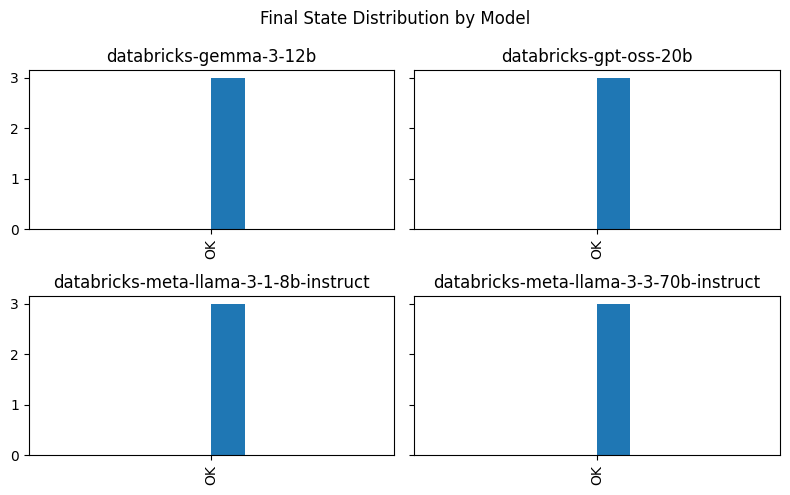

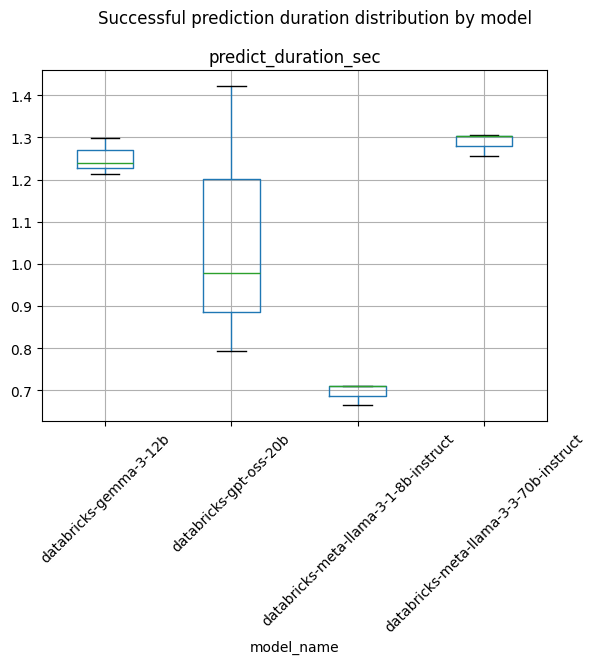

In [0]:
render_model_performance_plots(mlflow.search_traces(
    locations=[mlflow.get_experiment_by_name("/Shared/router_llm_performance").experiment_id],
), "router_agent_predict_with_retry")

### Routing Agent Model Selection

As shown above, all four evaluated LLMs achieved identical final states, successfully routing 100% of the test cases (`OK`). 

However, looking at the latency distributions, `databricks-meta-llama-3-1-8b-instruct` significantly outperformed the other LLMs. With a median response time of approximately 0.7 seconds, it operates roughly 30% to 45% faster than the other options, which consistently peaked between 1.0 and 1.3 seconds for inference.

Given its superior speed, high reliability, and inherently lower token cost as an 8B parameter model, `databricks-meta-llama-3-1-8b-instruct` is the clear choice to back the routing agent.

original_row_index final_state final_response agent_name model_name predict_duration_sec 0 OK {
 "assigned_department": "Billing Adjustments",
 "root_cause_analysis": "The customer reported a $35 late payment fee applied on June 1st despite having made timely payments. Transaction records retrieved for the account do not show a discrete fee entry, indicating the fee may have been applied as a backend adjustment not reflected in the exported transaction feed. This pattern aligns with historical complaints (e.g., Complaint_ID 187887) where unauthorized late fees were traced to a processing mis‑classification within the billing engine. According to the Northstar Billing & Transaction Errors playbook (PB001), such errors are classified as bank processing errors and qualify for fee reversal when the customer’s payment history demonstrates compliance with due‑date obligations.",
 "recommended_actions": [
 {
 "action_item": "Waive the $35 late payment fee and credit the amount back to the customer's account",
 "justification_source": "Northstar Financial Services - Customer Complaint Escalation Playbook (PB001) – Billing & Transaction Errors section; Historical precedent Complaint_ID 187887"
 },
 {
 "action_item": "Document the fee reversal in the account audit log and flag the transaction for review by the Billing Operations Manager to prevent recurrence",
 "justification_source": "Northstar Financial Services - Customer Complaint Escalation Playbook (PB001) – Internal Actions for billing errors"
 }
 ],
 "priority_level": "HIGH",
 "customer_email": {
 "subject": "[CASE #{{TRACKING_CODE}}] – Review of Your Late Payment Fee",
 "body": "Dear Valued Customer,\n\nThank you for reaching out and letting us know about the $35 late payment fee that was posted on June 1st. I understand how frustrating it can be to see a charge you believe is inaccurate, especially when you have a consistent record of paying on time.\n\nOur team has carefully reviewed your account activity and the billing records associated with this fee. Based on that review, we determined that the fee was applied in error due to an internal processing issue. In accordance with our Billing & Transaction Errors policy (Playbook PB001), we have reversed the $35 charge and the amount will be credited back to your account within the next 1‑2 business days.\n\nTo ensure this does not happen again, we have flagged your account for a secondary review by our Billing Operations Manager. This additional check helps us identify and correct any systemic issues that could affect other customers.\n\nWe appreciate your patience while we resolved this matter. If you have any further questions or need additional assistance, please do not hesitate to reply to this email or contact our Customer Support line.\n\nSincerely,\n\n[Your Name]\nSenior Operations Escalation Specialist\nNorthstar Financial Services"
 }
} reasoning_agent_predict_with_retry databricks-gpt-oss-120b 6.361240867 1 OK {
 "assigned_department": "Billing Adjustments",
 "root_cause_analysis": "The customer's transaction history does not contain a line item matching the disputed $35 late payment fee on June 1st; only regular Visa purchases are present. This discrepancy suggests the fee was applied through an internal processing routine rather than a merchant transaction. Given the absence of a legitimate fee trigger (e.g., missed payment or contract clause) and the customer’s track record of on‑time payments, the most probable root cause is a billing system error that incorrectly generated a late‑payment assessment. This aligns with historical precedent of similar billing disputes where the fee was erroneously posted and later reversed after internal verification.",
 "recommended_actions": [
 {
 "action_item": "Reverse the $35 late payment fee on the customer's account and issue a credit memo",
 "justification_source": "Northstar Financial Services Playbook PB001 – Section 'Billing & Transaction Errors' (branch managers may waive

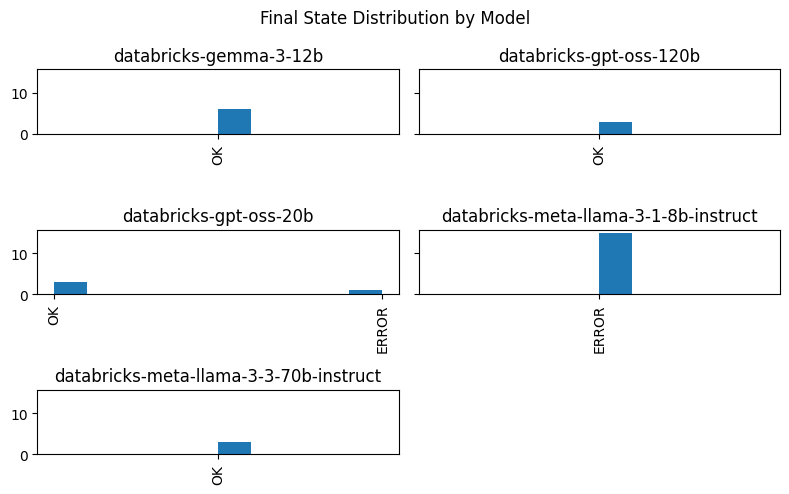

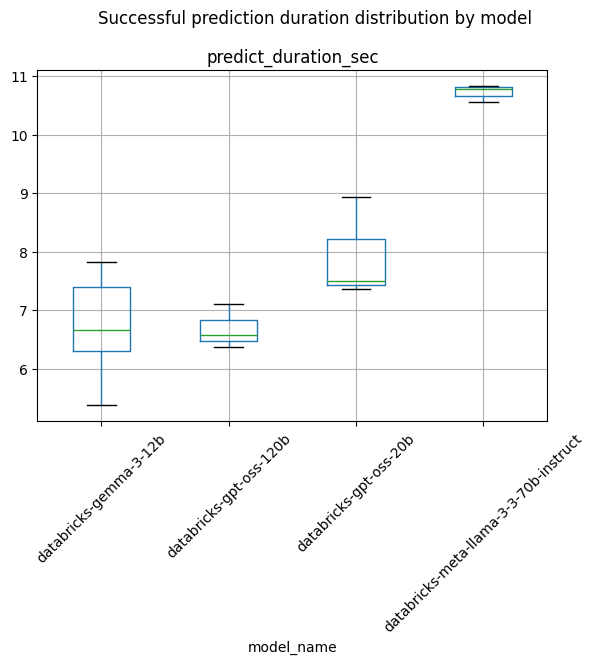

In [0]:
render_model_performance_plots(mlflow.search_traces(
    locations=[mlflow.get_experiment_by_name("/Shared/reasoning_llm_performance").experiment_id],
), "reasoning_agent_predict_with_retry")

### Reasoning Agent Model Selection

While `databricks-meta-llama-3-1-8b-instruct` was the optimal choice for the simpler routing task, the LLM suffered a 100% failure rate for the reasoning agent. Although the responses included JSON, it consistently failed to follow instructions precisely by adding conversational text around the JSON blocks. Similarly, `databricks-gpt-oss-20b` struggled with structural responses, periodically failing with the same error.

The other models (`databricks-gemma-3-12b`, `databricks-gpt-oss-120b`, and `databricks-meta-llama-3-3-70b-instruct`) achieved perfect reliability (`OK`) with valid JSON responses.

Evaluating the latency distributions for these successful runs:
- `databricks-meta-llama-3-3-70b-instruct` has consistent but slow performance, near 10.7 seconds.
- `databricks-gemma-3-12b` and `databricks-gpt-oss-120b` have a performance advantage with lower median latencies near 6.6 seconds.

Without reviewing the qualitative performance of the LLMs, the `databricks-gemma-3-12b` model appears to offer superior speed, lower cost using fewer parameters, and it follows instructions reasonably well.

**Next Steps:** To finalize our selection and verify qualitative accuracy beyond basic schema validation, we will run comprehensive evaluation pipelines across our 15 core test cases and directly compare the resulting text quality and domain-specific eval metrics.

In [0]:
mlflow.set_experiment("/Shared/evaluation_test_cases_gemma_reasoning")

test_case_results_gemma = []
for i, test_case in enumerate(evaluation_test_cases):
    try:
        print(f"Executing test case {i + 1}")
        result = run_workflow(
            test_case,
            router_llm="databricks-meta-llama-3-1-8b-instruct",
            reasoning_llm="databricks-gemma-3-12b",
        )
        test_case_results_gemma.append(result)
        write_prediction(result)
    except Exception as e:
        print(f"Failed to complete workflow for test case: {test_case}")
        test_case_results_gemma.append(None)
        print(e)
    finally:
        print()

2026/06/17 07:54:08 INFO mlflow.tracking.fluent: Experiment with name '/Shared/evaluation_test_cases_gemma_reasoning' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


Executing test case 1
Wrote prediction to main.default.predictions

Executing test case 2
Wrote prediction to main.default.predictions

Executing test case 3
Wrote prediction to main.default.predictions

Executing test case 4
Wrote prediction to main.default.predictions

Executing test case 5
Wrote prediction to main.default.predictions

Executing test case 6
Wrote prediction to main.default.predictions

Executing test case 7
Wrote prediction to main.default.predictions

Executing test case 8
Wrote prediction to main.default.predictions

Executing test case 9
Wrote prediction to main.default.predictions

Executing test case 10
Wrote prediction to main.default.predictions

Executing test case 11
Wrote prediction to main.default.predictions

Executing test case 12
Wrote prediction to main.default.predictions

Executing test case 13
Out of scope, not writing to main.default.predictions

Executing test case 14
Out of scope, not writing to main.default.predictions

Executing test case 15
Ou

[Trace(trace_id=tr-36d6365ea998d1de099cb885fe198f5f), Trace(trace_id=tr-95e6742526a7ae99b4d9c2e72bba3453), Trace(trace_id=tr-cf13711d282c8faf7d4006106ae9b778), Trace(trace_id=tr-84e9343132bc15bd72e83e6cd1d9f75b), Trace(trace_id=tr-13ad524be86cb7f913c2d5fcb0c350a1), Trace(trace_id=tr-e8feab835a9d12ab6332f8a55ae391dd), Trace(trace_id=tr-1d6a53732fd0ec57389a4012d236f757), Trace(trace_id=tr-22456b3f34d8907f83feff13036b89ab), Trace(trace_id=tr-3ee2de47c7f8be061b5dfcc2fd492161), Trace(trace_id=tr-a91ebf7083d60aca840758a7afec0d8e)]

In [0]:
# === Run LLM-as-a-Judge on the workflow output ===
mlflow.set_experiment("/Shared/evaluation_test_cases_gemma_reasoning_judge")
for i, test_case_result in enumerate(test_case_results_gemma):
    # Extract the agent output from the workflow response
    if test_case_result is None:
        print(f"Skipping evaluation for test case {i} (failed to complete workflow)")
        continue
    final_result = test_case_result.output[-1].content[0]["text"]
    agent_output = json.loads(final_result)

    # Format agent output as a readable string for evaluation
    if "is_in_scope" in agent_output and not agent_output["is_in_scope"]:
        agent_output_text = agent_output.get("rejection_response", str(agent_output))
    else:
        # For in-scope complaints, format the customer email
        customer_email = agent_output.get("customer_email", {})
        agent_output_text = f"Subject: {customer_email.get('subject', '')}\n\n{customer_email.get('body', '')}"

    function_calls = [i for i in test_case_results[0].output if i.type == "function_call"]
    function_call_outputs = [i for i in test_case_results[0].output if i.type == "function_call_output"]
    function_call_context = "\n".join([
        f"Function Call: {function_call.name.replace('__', '.')}\nFunction Call Output: {function_call_output.output}"
        for function_call, function_call_output in zip(function_calls, function_call_outputs)
    ])

    print(f"=== LLM-as-a-Judge Evaluation (Test Case: {i + 1}) ===")

    # Run the judge
    evaluation = evaluate_escalation(
        complaint=evaluation_test_cases[i],
        agent_output=agent_output_text,
        retrieved_context=function_call_context,
    )

    # Display results nicely
    print(f"Overall Score: {evaluation.overall_score}/5")
    print(f"Relevance: {evaluation.relevance_score}/5")
    print(f"Grounding: {evaluation.grounding_score}/5")
    print(f"Policy Compliance: {evaluation.policy_compliance_score}/5")
    print(f"Professionalism: {evaluation.professionalism_score}/5")
    print(f"\nJustification:\n{evaluation.justification}")
    print()

2026/06/17 07:56:45 INFO mlflow.tracking.fluent: Experiment with name '/Shared/evaluation_test_cases_gemma_reasoning_judge' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


=== LLM-as-a-Judge Evaluation (Test Case: 1) ===
Overall Score: 3/5
Relevance: 5/5
Grounding: 1/5
Policy Compliance: 2/5
Professionalism: 5/5

Justification:
The response is highly relevant and professional in tone, directly addressing the customer's complaint about the late fee. However, it fails critically on grounding and policy compliance. The retrieved transaction history does not contain a record of the $35 late fee (it only lists Visa purchases), yet the agent claims to have verified and reversed the fee. The evaluation instructions explicitly require verifying that the transaction to reverse exists in the retrieved context before processing a refund. Additionally, the playbook requires confirming a bank processing error before waiving fees, a step the agent bypasses by immediately confirming the reversal without evidence from the provided context.

=== LLM-as-a-Judge Evaluation (Test Case: 2) ===
Overall Score: 3/5
Relevance: 5/5
Grounding: 1/5
Policy Compliance: 2/5
Profession


### Performance and Trade-off analysis

The original `databricks-meta-llama-3-3-70b-instruct` model achieved a 61 out of 75 overall score, while `databricks-gemma-3-12b` achieved 54 out of 75.

Reviewing the judges responses, `databricks-gemma-3-12b` failed to cross-reference the tool-provided context and also hallucinated actions that it performed. This presents significant business risk for the following reasons:
- **Compliance Risks and Lack of Data Verification:** Failure to verify transaction records (Test Cases 1 & 2) can result in refunds and payouts without verifying the authenticity of the customer's request.
- **Security and Policy Hallucinations:** In multiple test cases, Gemma hallucinated instead of strictly following instructions. In test case 5, Gemma stated that it disabled the customer's 2FA security and issued a temporary password, which Gemma did not have the tools to do. This action is also not consistent with the business playbook. Additionally, Gemma created unauthorized courtesy credits in test case 6 to compensate for long wait times, which is also not supported by the business playbook. Llama strictly adhered to the escalation playbooks, routing the issues to the proper teams without severe hallucinations.
- **Failure to Communicate Rigid SLAs:** The business playbook mandates communicating clear, strict timelines to users based on their complaint type. Gemma consistently provided vague timelines, whereas Llama explicitly quoted the mandated 3-business-day or 5-business-day windows.

### Final Recommendation

While both models maintained a perfect 100% structural execution rate (successfully outputting parseable JSON), Gemma's tendency to hallucinate makes it a high-risk liability for a user-facing deployment of a financial product.

The evaluation metrics support using `databricks-meta-llama-3-3-70b-instruct` to back the reasoning agent.